# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [1]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_raw_macro.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="timepoint" # stream2 or timepoint

In [2]:
import sys
#!pip install gseapy
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import gseapy as gp
from gseapy import get_library
from scipy.stats import fisher_exact
import json
#! pip install goatools
#!pip install leidenalg

In [3]:
warnings.filterwarnings("ignore")
adata = sc.read(input_file) # read data 
if adata.X.max() > 10 : # check if is raw data, need to be > 10
    # Normalization
    sc.pp.normalize_total(adata) # 
    sc.pp.log1p(adata)
    print("=== This dataset is now normalised")
else :
    print("=== This dataset appears to have already been normalised")

# Verify if we have only the cells expected and the macrostates 
print("=== Cell type and macrostates in our dataset")
print(adata.obs["Annotation"].unique())
print(adata.obs["macrostates"].unique())

=== This dataset is now normalised
=== Cell type and macrostates in our dataset
['B intermediate' 'B naive' 'B' 'B memory' 'Bridge']
['I2' 'None' 'I1' 'T1' 'T3' 'T2']


# Definition of the majority vote


Processing I1...
  5018 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted

Processing I2...
  1015 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted

Processing T1...
  264 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted

Processing T2...
  1797 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted

Processing T3...
  1699 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted


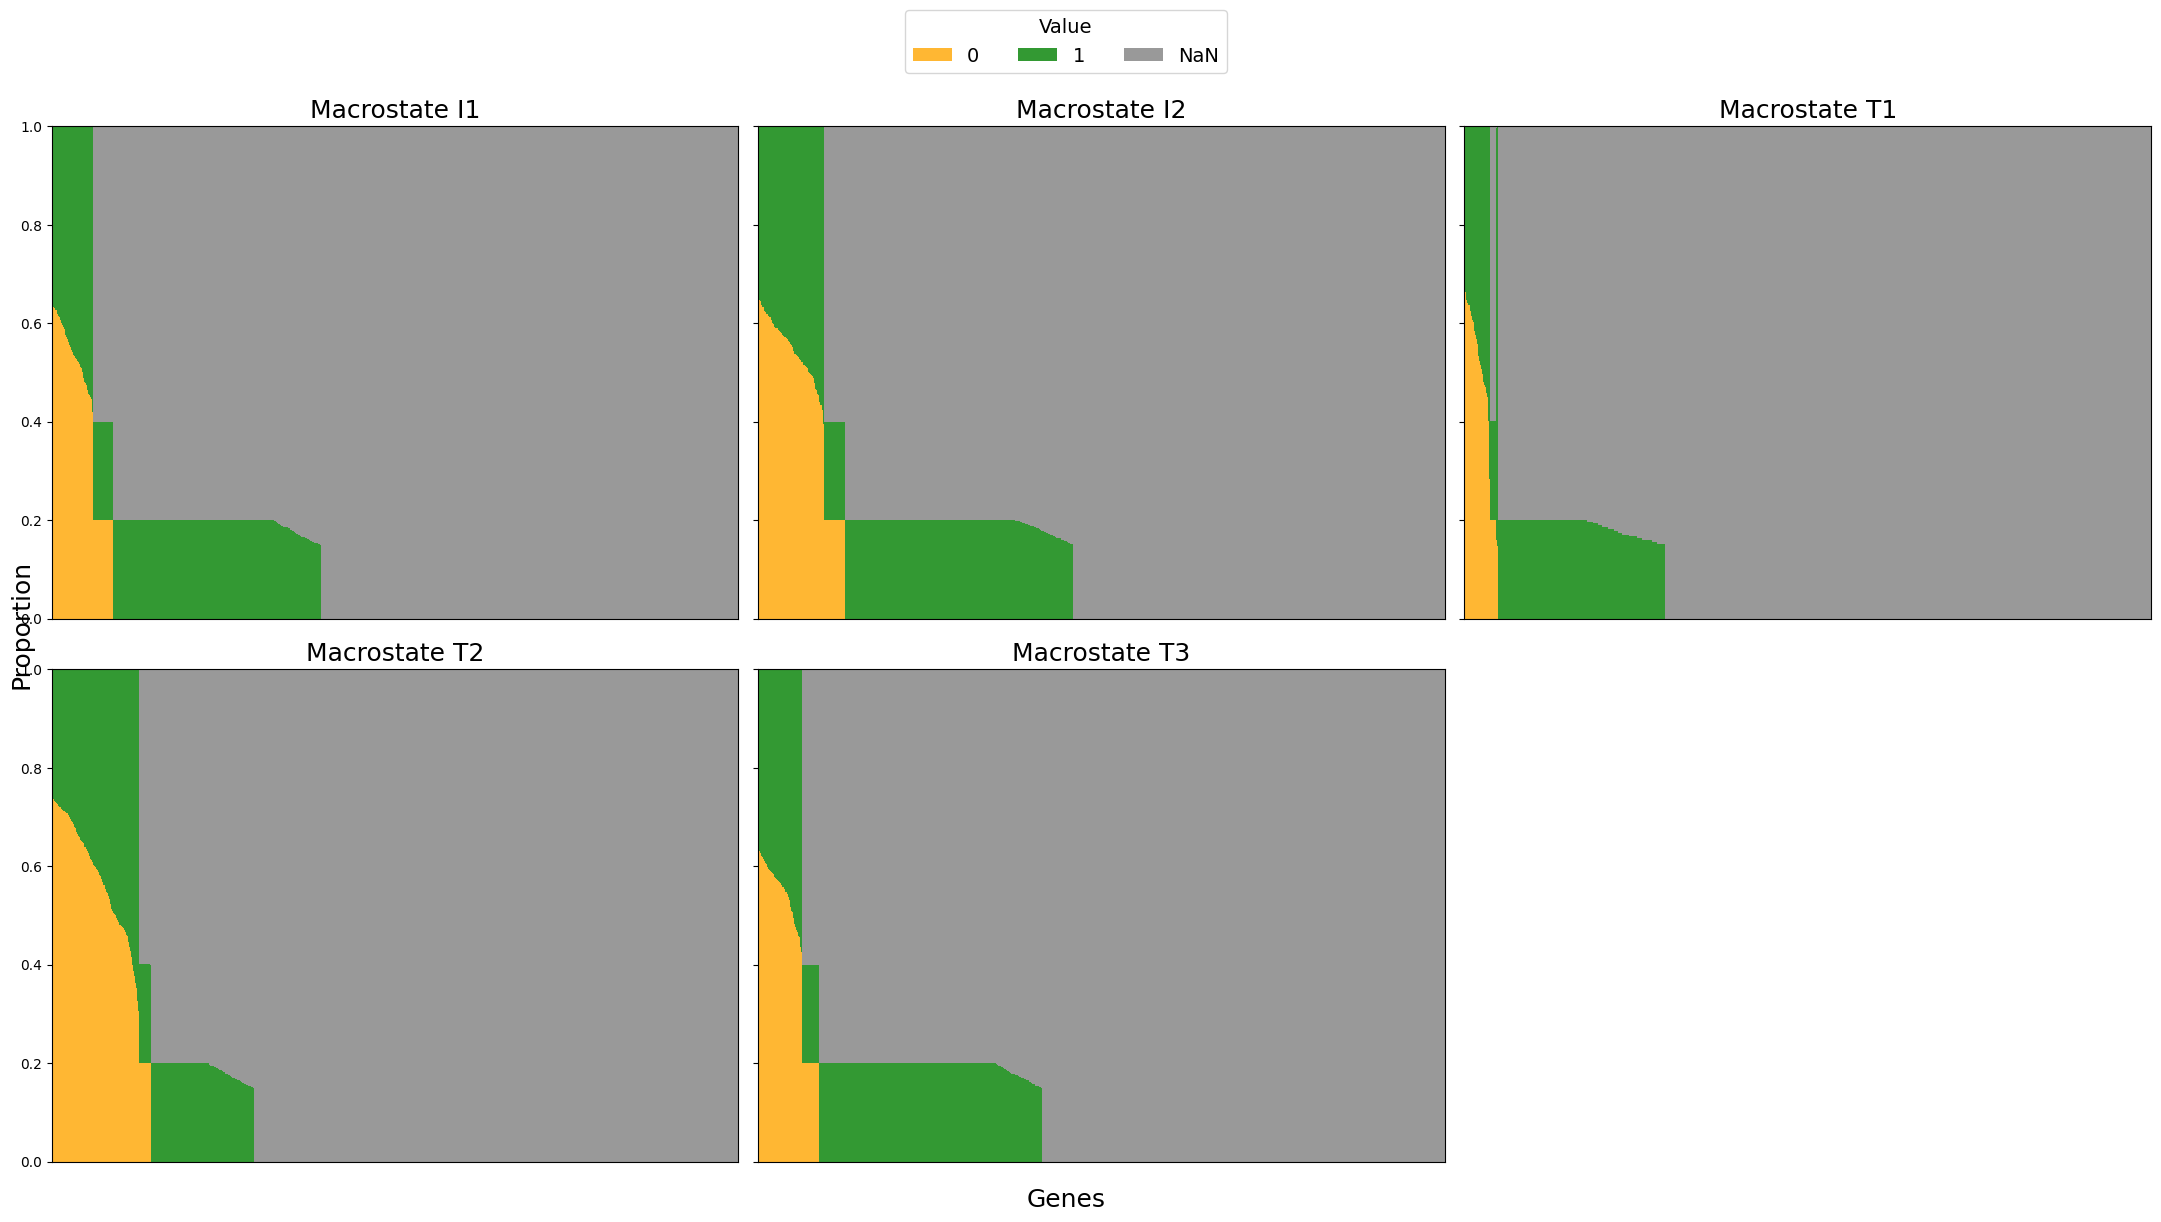

In [5]:
warnings.filterwarnings("ignore")

macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']

binarized_states = {}
all_hvg = set()
adata_ct_dict = {}

# One figure 
fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ct in enumerate(macrostates):
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")

    ax = axes[i]

    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index
    all_hvg.update(hvg_genes)

    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : scBoolSeq
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",
        margin_quantile=0.2,
        dor_threshold=0.85,
        alpha=0
    )

    scbool.fit(expr_df_full)
    print("  scBoolSeq fitted")

    # STEP 4 : Binarization
    binarized = scbool.binarize(expr_df_full)

    # STEP 5 : proportions
    n_cells = len(binarized)

    proportions = pd.DataFrame({
        '0': binarized.apply(lambda col: (col == 0.0).sum() / n_cells).values,
        '1': binarized.apply(lambda col: (col == 1.0).sum() / n_cells).values,
        'NaN': binarized.apply(lambda col: col.isna().sum() / n_cells).values
    })

    proportions = proportions.sort_values(
        ['0', '1'],
        ascending=[False, False]
    ).reset_index(drop=True)

    x = np.arange(len(proportions))

    ax.bar(x, proportions['0'], width=1.0, color='orange', alpha=0.8, label='0')
    ax.bar(x, proportions['1'], width=1.0, bottom=proportions['0'],
           color='green', alpha=0.8, label='1')
    ax.bar(x, proportions['NaN'], width=1.0,
           bottom=proportions['0'] + proportions['1'],
           color='gray', alpha=0.8, label='NaN')

    ax.set_xlim(-0.5, len(proportions) - 0.5)
    ax.margins(x=0)
    ax.set_title(f'Macrostate {ct}', fontsize=18)
    ax.set_xticks([])

    del adata_ct, expr_df_full, scbool
    gc.collect()

fig.delaxes(axes[5])

# Axis
fig.supxlabel("Genes", fontsize=18)
fig.supylabel("Proportion", fontsize=18)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles,labels,title="Value",loc="upper center",ncol=3,fontsize=14,title_fontsize=14,bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{output_directory}/proportions_scboolseq_all_macrostates.png",dpi=200,bbox_inches="tight")
plt.show()

In [7]:
all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])
print(f"Total genes: {len(all_genes)}")
print(f"HVG macrostates: {hvg_mask.sum()} genes")

Total genes: 18723
HVG macrostates: 6214 genes


Binarization basic count >=1 =1, count=0 =0

In [4]:
warnings.filterwarnings("ignore")

macrostates = ['I1', 'I2', 'T1', 'T2', "T3"]

binarized_states = {}
all_hvg = set()
adata_ct_dict = {}

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")
        
    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : HVG adapted to the cell type size
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : Building the DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    # Eliminate the 0 genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : Binarize per macrostate
    # Binairization with a threshold : ~0 UMI (log(1))
    threshold = np.log(1)
    binarized = (expr_df_full > threshold).astype(int)

    print(f" {binarized.shape[1]} genes binarized")
    print(f"  Binarization done")

    # STEP 4 : produce plot
    n_cells = len(binarized)
    proportions = pd.DataFrame({
        '0': binarized.apply(lambda col: (col == 0.0).sum() / n_cells).values,
        '1': binarized.apply(lambda col: (col == 1.0).sum() / n_cells).values,
        'NaN': binarized.apply(lambda col: col.isna().sum() / n_cells).values
    })

    # Order
    proportions = proportions.sort_values(['0', '1'], ascending=[False, False]).reset_index(drop=True)
        
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(proportions))

    ax.bar(x, proportions['0'], width=1.0, label='0', color='orange', alpha=0.8)
    ax.bar(x, proportions['1'], width=1.0, bottom=proportions['0'], label='1', color='green', alpha=0.8)
    ax.bar(x, proportions['NaN'], width=1.0, bottom=proportions['0'] + proportions['1'], label='NaN', color='gray', alpha=0.8)

    ax.set_xlim(-0.5, len(proportions) - 0.5)
    ax.margins(x=0)
        
    ax.set_ylabel('Proportion', fontsize=16)
    ax.set_xlabel('Genes', fontsize=16)
    ax.set_title(f'Macrostate {ct}', fontsize=20)
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=14) 
        
    # Legend
    ax.legend(title='Value', loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f'{output_directory}/proportions_basic_{ct}.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

    del adata_ct, expr_df_full
    gc.collect()

print("\nDone!")


Processing I1...
  5018 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing I2...
  1015 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T1...
  264 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T2...
  1797 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T3...
  1699 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Done!



Processing I1...
  5018 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing I2...
  1015 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T1...
  264 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T2...
  1797 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T3...
  1699 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done


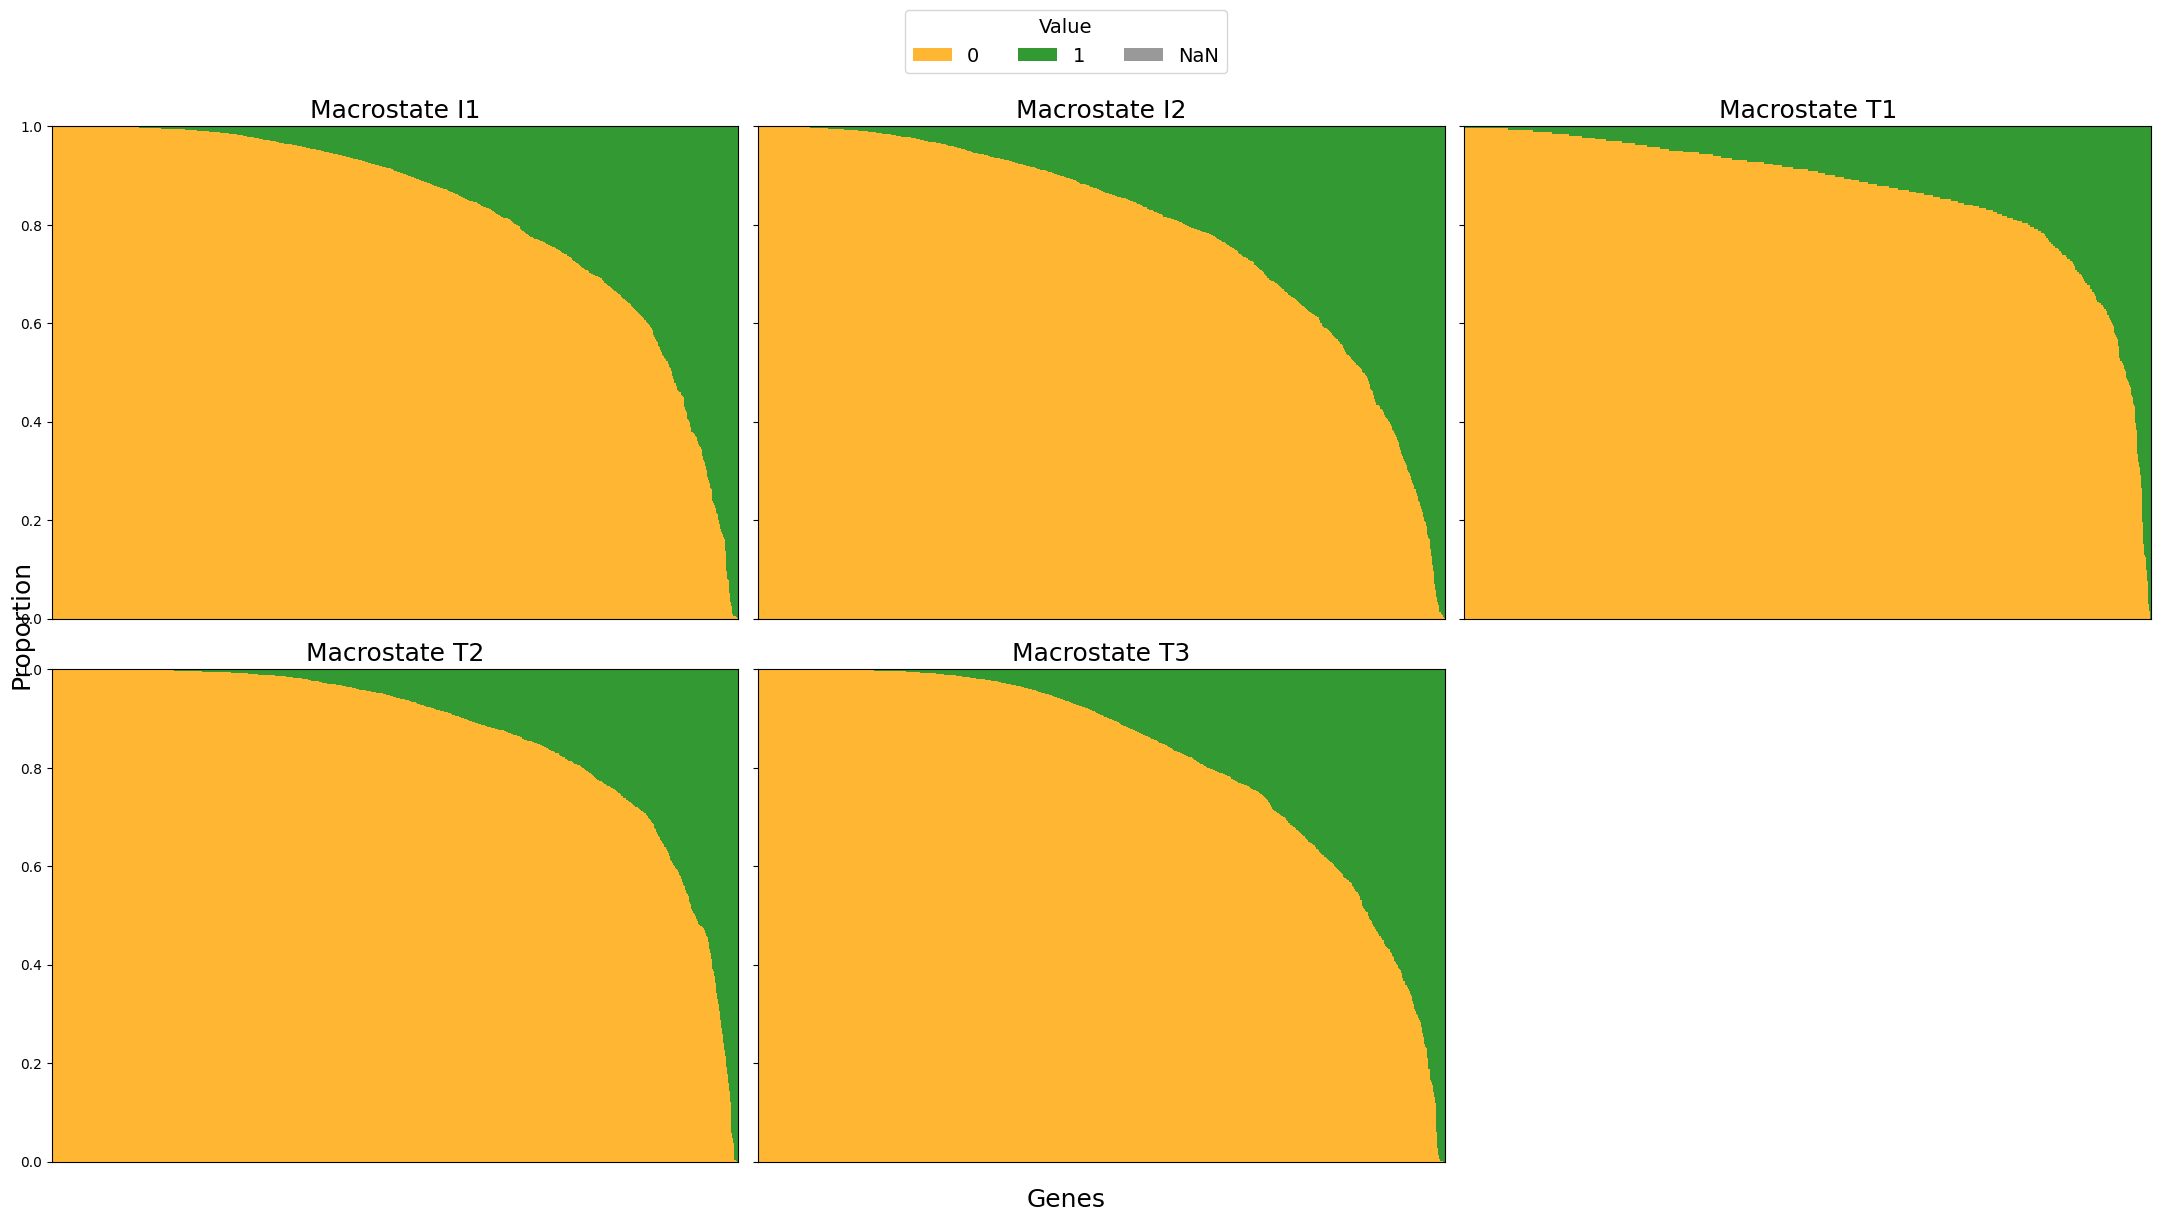

In [7]:
warnings.filterwarnings("ignore")

macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']

binarized_states = {}
all_hvg = set()
adata_ct_dict = {}

# One figure 
fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ct in enumerate(macrostates):
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")

    ax = axes[i]

    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index
    all_hvg.update(hvg_genes)

    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : Binarize per macrostate
    # Binairization with a threshold : ~0 UMI (log(1))
    threshold = np.log(1)
    binarized = (expr_df_full > threshold).astype(int)

    print(f" {binarized.shape[1]} genes binarized")
    print(f"  Binarization done")

    # STEP 4 : Plots
    n_cells = len(binarized)

    proportions = pd.DataFrame({
        '0': binarized.apply(lambda col: (col == 0.0).sum() / n_cells).values,
        '1': binarized.apply(lambda col: (col == 1.0).sum() / n_cells).values,
        'NaN': binarized.apply(lambda col: col.isna().sum() / n_cells).values
    })

    proportions = proportions.sort_values(
        ['0', '1'],
        ascending=[False, False]
    ).reset_index(drop=True)

    x = np.arange(len(proportions))

    ax.bar(x, proportions['0'], width=1.0, color='orange', alpha=0.8, label='0')
    ax.bar(x, proportions['1'], width=1.0, bottom=proportions['0'],
           color='green', alpha=0.8, label='1')
    ax.bar(x, proportions['NaN'], width=1.0,
           bottom=proportions['0'] + proportions['1'],
           color='gray', alpha=0.8, label='NaN')

    ax.set_xlim(-0.5, len(proportions) - 0.5)
    ax.margins(x=0)
    ax.set_title(f'Macrostate {ct}', fontsize=18)
    ax.set_xticks([])

    del adata_ct, expr_df_full
    gc.collect()

fig.delaxes(axes[5])

# Axis
fig.supxlabel("Genes", fontsize=18)
fig.supylabel("Proportion", fontsize=18)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles,labels,title="Value",loc="upper center",ncol=3,fontsize=14,title_fontsize=14,bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{output_directory}/proportions_basic_all_macrostates.png",dpi=200,bbox_inches="tight")
plt.show()


Processing I1...
  5018 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted


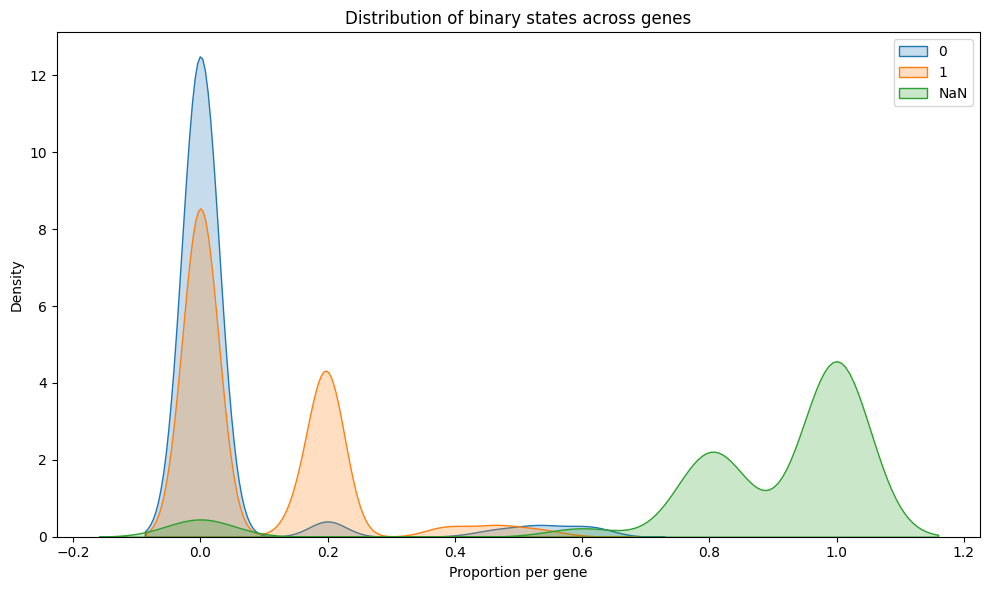


Processing I2...
  1015 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted


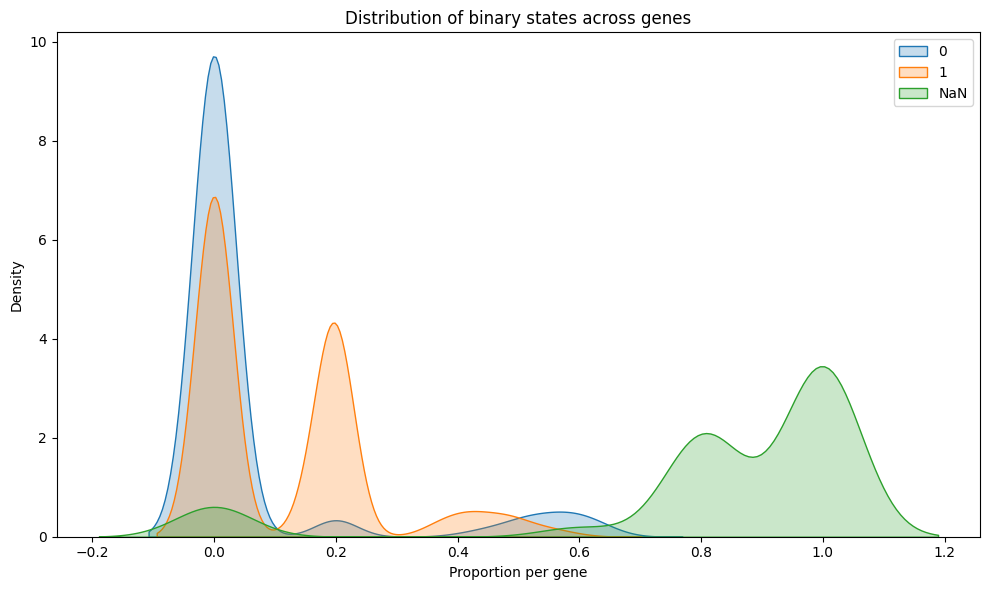


Processing T1...
  264 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted


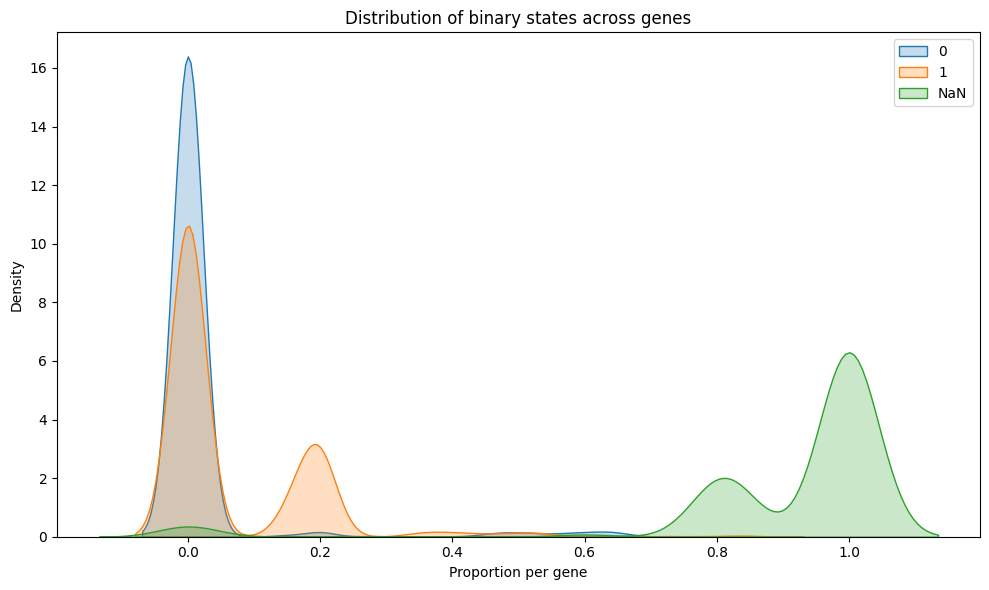


Processing T2...
  1797 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted


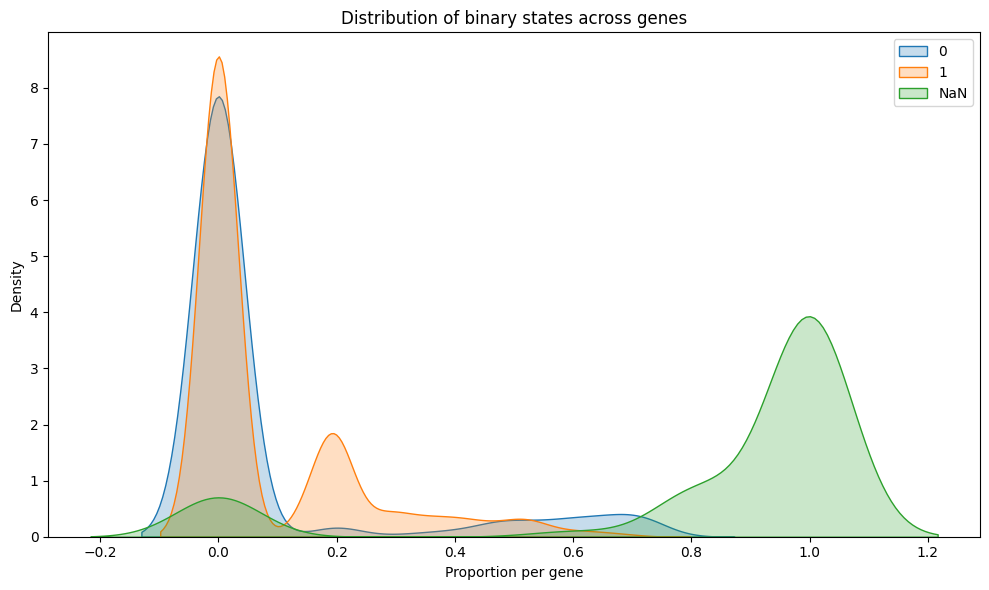


Processing T3...
  1699 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted


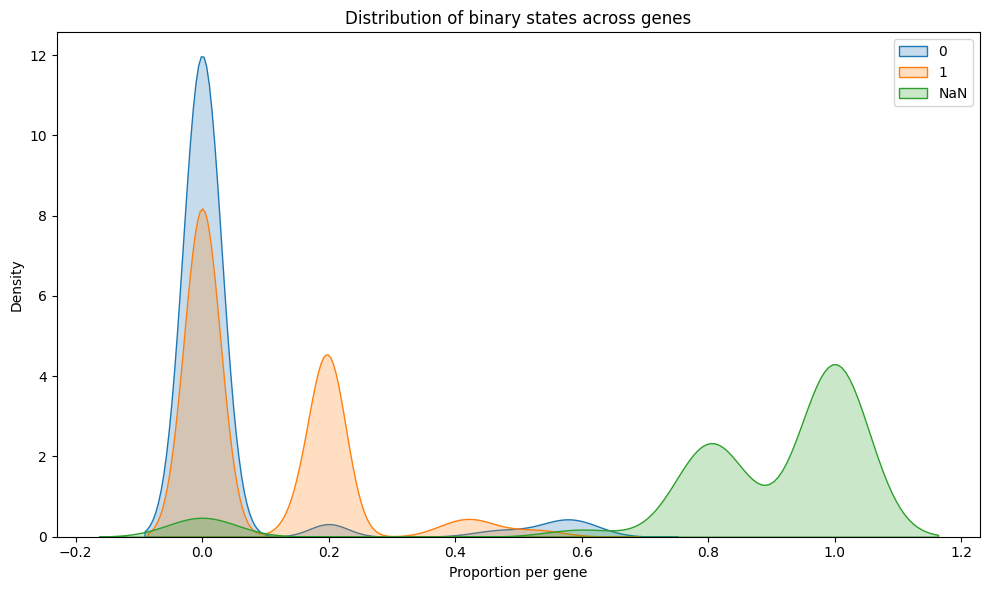

In [11]:
warnings.filterwarnings("ignore")

macrostates = ['I1', 'I2', 'T1', 'T2', "T3"]

binarized_states = {}
all_hvg = set()
adata_ct_dict = {}

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")

    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : scBoolSeq model
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",
        margin_quantile=0.2,
        dor_threshold=0.85,
        alpha=0
    )

    scbool.fit(expr_df_full)
    scbool.criteria_.to_csv(
        f"/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/criteria_scboolseq_{ct}.csv"
    )
    print("  scBoolSeq fitted")

        # STEP 4 : Binarization
    binarized = scbool.binarize(expr_df_full)

        # STEP 5 : Distrubition
    n_cells = len(binarized)

    gene_props = pd.DataFrame({
        "0": (binarized == 0).sum(axis=0) / n_cells,
        "1": (binarized == 1).sum(axis=0) / n_cells,
        "NaN": binarized.isna().sum(axis=0) / n_cells
    })

    plt.figure(figsize=(10,6))

    sns.kdeplot(gene_props["0"], label="0", fill=True)
    sns.kdeplot(gene_props["1"], label="1", fill=True)
    sns.kdeplot(gene_props["NaN"], label="NaN", fill=True)

    plt.xlabel("Proportion per gene")
    plt.ylabel("Density")
    plt.title("Distribution of binary states across genes")
    plt.legend()
    plt.tight_layout()
    plt.show()

    del adata_ct, expr_df_full, scbool
    gc.collect()


Processing I1...
5018 cells
2000 HVGs selected

Processing I2...
1015 cells
2000 HVGs selected

Processing T1...
264 cells
2000 HVGs selected

Processing T2...
1797 cells
2000 HVGs selected

Processing T3...
1699 cells
2000 HVGs selected


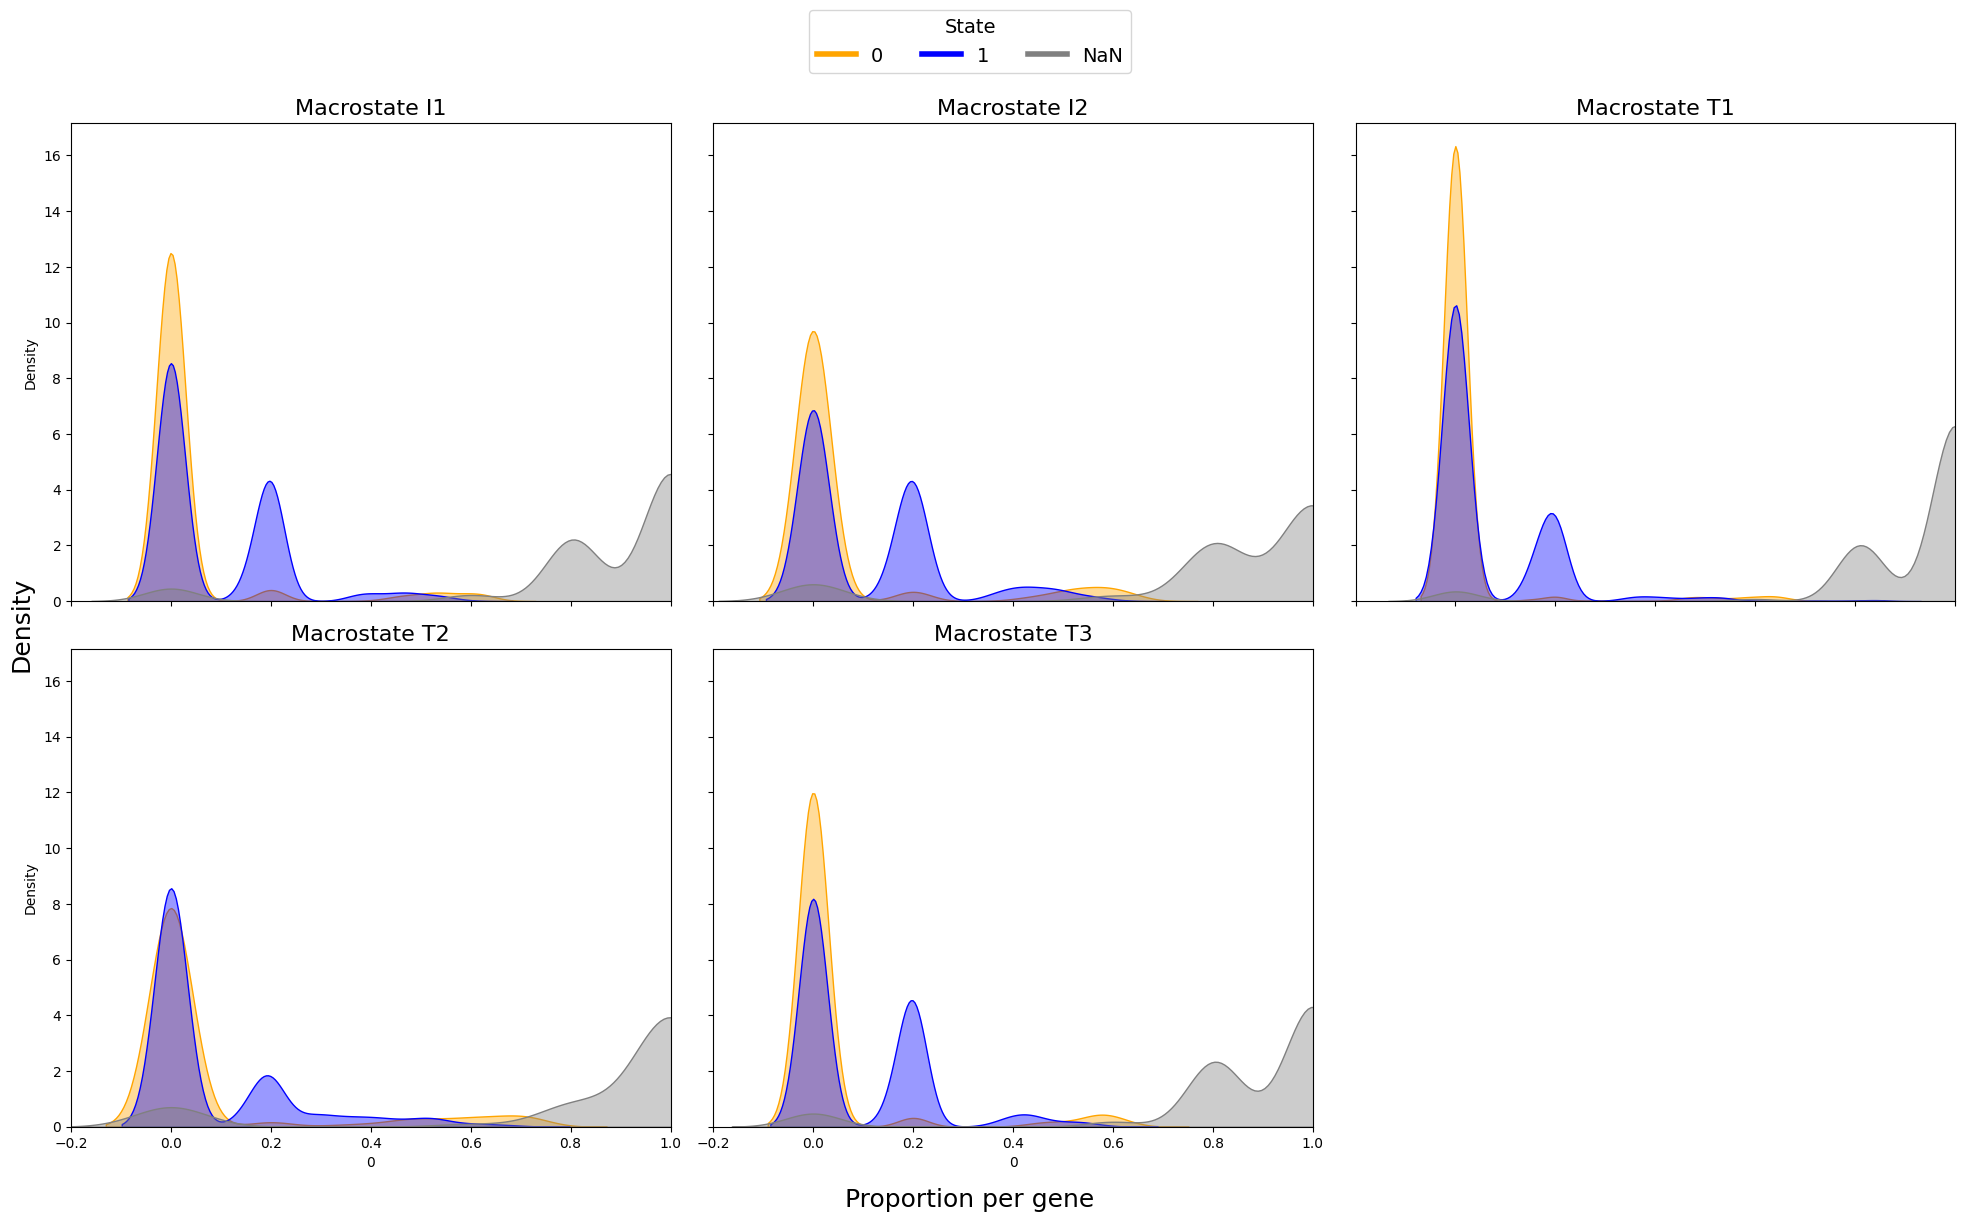

In [15]:
warnings.filterwarnings("ignore")
macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ct in enumerate(macrostates):

    print(f"\n{'='*50}")
    print(f"Processing {ct}...")

    ax = axes[i]

    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"{n_cells} cells")

    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()

    print(f"{adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : dataframe
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]


    # STEP 3 : scBoolSeq
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",
        margin_quantile=0.2,
        dor_threshold=0.85,
        alpha=0
    )

    scbool.fit(expr_df_full)
    binarized = scbool.binarize(expr_df_full)

    # STEP 4 : proportions per gene
    n_cells = len(binarized)

    gene_props = pd.DataFrame({
        "0": (binarized == 0).sum(axis=0) / n_cells,
        "1": (binarized == 1).sum(axis=0) / n_cells,
        "NaN": binarized.isna().sum(axis=0) / n_cells
    })

    # STEP 5 : plot
    sns.kdeplot(
        gene_props["0"],
        fill=True,
        alpha=0.4,
        color="orange",
        label="0",
        ax=ax
    )

    sns.kdeplot(
        gene_props["1"],
        fill=True,
        alpha=0.4,
        color="blue",
        label="1",
        ax=ax
    )

    sns.kdeplot(
        gene_props["NaN"],
        fill=True,
        alpha=0.4,
        color="gray",
        label="NaN",
        ax=ax
    )

    ax.set_title(f"Macrostate {ct}", fontsize=16)
    ax.set_xlim(-0.2, 1)

    if ax.get_legend():
        ax.get_legend().remove()

    del adata_ct, expr_df_full, scbool
    gc.collect()

fig.delaxes(axes[5])

# Axis
fig.supxlabel("Proportion per gene", fontsize=18)
fig.supylabel("Density", fontsize=18)

# Legende
handles = [
    plt.Line2D([0], [0], color="orange", lw=4),
    plt.Line2D([0], [0], color="blue", lw=4),
    plt.Line2D([0], [0], color="gray", lw=4)
]

labels = ["0", "1", "NaN"]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=14,
    title="State",
    title_fontsize=14,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    f"{output_directory}/distribution_scboolseq_all_macrostates.png",
    dpi=200,
    bbox_inches="tight")

plt.show()